# Introduccion a Clasificacion
El objetivo de este notebook es comprender qué es un problema de clasificación y cómo la inteligencia artificial ha permitido desarrollar modelos capaces de analizar patrones en los datos para generar predicciones.

En este Jupyter Notebook nos enfocaremos en algoritmos de Machine Learning orientados a la clasificación, una tarea fundamental para avanzar hacia problemas más complejos, incluyendo aquellos relacionados con la inteligencia artificial generativa.

Esta sección continúa el material enfocado en predicciones dentro del aprendizaje supervisado. Recordemos que este campo se divide principalmente en dos áreas: regresión y clasificación. En el notebook anterior se hizo énfasis en regresión, donde el objetivo es predecir una variable numérica. En contraste, en clasificación el objetivo es predecir una clase o categoría.

## Que es clasificacion?
La **clasificación** es una de las tareas fundamentales en *Machine Learning* y consiste en **asignar una etiqueta o categoría a un dato de entrada** a partir de sus características.

En términos simples, el objetivo es aprender una función que, dado un conjunto de ejemplos previamente etiquetados (datos de entrenamiento), pueda predecir correctamente la clase de nuevos datos.

Ejemplos:
- Determinar si un correo es *spam* o *no spam*  
- Clasificar una imagen como *perro* o *gato*  
- Identificar si una transacción es *fraudulenta* o *legítima*
- Identificar si una radiografia contiene un cancer o no.

Formalmente, la clasificación es un tipo de **aprendizaje supervisado**, donde el modelo aprende a partir de pares:

$$
(x, y)
$$

donde:
- \( x \) = características (*features*)
- \( y \) = etiqueta (*clase*)

---

### Ejemplo sencillo

Supongamos que queremos clasificar si un correo es *spam* o *no spam*.

Un dataset de entrenamiento podría verse así:

| Número de palabras | Contiene "gratis" | Nº exclamaciones | Etiqueta |
|------------------|-------------------|------------------|----------|
| 120              | Sí                | 5                | Spam     |
| 45               | No                | 0                | No Spam  |
| 200              | Sí                | 10               | Spam     |
| 60               | No                | 1                | No Spam  |
| 150              | Sí                | 3                | Spam     |

En este caso:
- Cada fila es un ejemplo \((x, y)\)
- Las primeras columnas son \( x \) (características)
- La última columna es \( y \) (la clase)

El modelo aprende patrones a partir de este dataset para clasificar nuevos correos automáticamente.

---

## Importancia de la Clasificación

La clasificación es clave porque:

- Es una de las tareas más comunes en problemas reales  
- Permite automatizar decisiones que antes requerían intervención humana  
- Es la base para sistemas inteligentes en múltiples industrias  
- Sirve como punto de entrada para entender conceptos más avanzados (como redes neuronales o NLP)

Además, muchos problemas complejos pueden reformularse como problemas de clasificación, lo que la convierte en una herramienta extremadamente versátil.

---

## Aplicaciones Comunes

La clasificación se utiliza en una gran variedad de dominios:

### Procesamiento de texto
- Detección de *spam*
- Análisis de sentimientos (*positivo*, *negativo*, *neutral*)

### Visión por computadora
- Reconocimiento de objetos
- Clasificación de imágenes médicas (ej. detección de tumores)

### Finanzas
- Detección de fraude
- Evaluación de riesgo crediticio

### Salud
- Diagnóstico asistido
- Clasificación de enfermedades

### Sistemas inteligentes
- Sistemas de recomendación como el de netflix
- Clasificación de usuarios o comportamientos

---

## Material recomendado
- https://www.youtube.com/watch?v=8-nt3Urok4E
- https://www.youtube.com/watch?v=XDG0r7Epn0A

## Clasificación binaria con scikit-learn

En este notebook nos enfocaremos en un problema de **clasificación binaria** utilizando **scikit-learn**, una de las bibliotecas más utilizadas en Python para aprendizaje automático.

La clasificación binaria consiste en predecir una de dos posibles clases. En este caso, el objetivo será determinar si una persona **tiene diabetes** o **no tiene diabetes** a partir de diferentes características relacionadas con su salud.

Al igual que en regresión, en clasificación es posible entrenar y comparar múltiples algoritmos con el fin de identificar cuál ofrece el mejor rendimiento según distintas métricas de evaluación. En este notebook exploraremos este proceso paso a paso, desde la carga y preparación de los datos hasta el entrenamiento, evaluación e interpretación de los resultados.

---

## Objetivo del notebook

Utilizaremos un dataset de salud como ejemplo introductorio para construir modelos capaces de predecir diabetes. A lo largo del notebook aprenderemos a:

1. Cargar y explorar el dataset  
2. Identificar las variables de entrada y la variable objetivo  
3. Preparar los datos para entrenamiento  
4. Separar los datos en conjuntos de entrenamiento y prueba  
5. Entrenar diferentes modelos de clasificación  
6. Evaluar el rendimiento de cada modelo con métricas apropiadas  
7. Interpretar probabilidades de predicción y ajustar el umbral de decisión  
8. Visualizar el desempeño del modelo con herramientas como la matriz de confusión y la curva ROC  

---

## Dataset

En este notebook utilizaremos el siguiente dataset:

**Health Care Diabetes Dataset**  
Fuente: Kaggle

Este conjunto de datos contiene información de pacientes y variables relacionadas con su estado de salud. A partir de estas variables, se busca predecir si el paciente presenta diabetes o no.

---

## Variable objetivo

La variable objetivo es la etiqueta que queremos predecir. En este problema, la salida tiene dos posibles valores:

- **1**: la persona tiene diabetes  
- **0**: la persona no tiene diabetes  

Por esta razón, este problema se considera de **clasificación binaria**.

---

## Características del dataset

Cada fila del dataset representa un paciente, y cada columna describe alguna característica relevante para el problema. Las variables que se incluyen son las siguientes:

- **Pregnancies**: número de embarazos que ha tenido la paciente  
- **Glucose**: concentración de glucosa en sangre  
- **BloodPressure**: presión arterial (mm Hg)  
- **SkinThickness**: grosor del pliegue cutáneo (indicador indirecto de grasa corporal)  
- **Insulin**: nivel de insulina en sangre  
- **BMI** (*Body Mass Index*): índice de masa corporal  
- **DiabetesPedigreeFunction**: medida que representa la predisposición genética a diabetes  
- **Age**: edad del paciente 
- **PhysicalActivity**:  representa que tanta actividad hace ek paciente. (bajo, medio, alto)
- **Outcome**: variable objetivo  
  - 1 → tiene diabetes  
  - 0 → no tiene diabetes  

Estas variables serán nuestras **características de entrada** o **features**, es decir, la información que usará el modelo para aprender patrones y realizar predicciones.

En términos de aprendizaje automático:

- \( x \) representa las características del paciente  
- \( y \) representa la clase o etiqueta a predecir  

Es decir:

$$
(x, y)
$$

donde:
- \( x \) = variables de entrada del paciente  
- \( y \) = diagnóstico: diabetes o no diabetes  

---

## Ejemplo simplificado del dataset

La siguiente tabla muestra cómo podría verse una pequeña parte del dataset:

 Pregnancies | Glucose | BloodPressure | SkinThickness | Insulin | BMI  | DiabetesPedigreeFunction | Age | PhysicalActivity | Outcome |
|------------|--------|---------------|---------------|---------|------|---------------------------|-----|------------------|---------|
| 2          | 148    | 72            | 35            | 0       | 33.6 | 0.627                     | 50  | Bajo             | 1       |
| 0          | 85     | 66            | 29            | 0       | 26.6 | 0.351                     | 31  | Alto             | 0       |
| 3          | 183    | 64            | 0             | 0       | 23.3 | 0.672                     | 32  | Medio            | 1       |
| 1          | 89     | 66            | 23            | 94      | 28.1 | 0.167                     | 21  | Alto             | 0       |
| 5          | 116    | 74            | 0             | 0       | 25.6 | 0.201                     | 30  | Medio            | 0       |

---


En este ejemplo:

- Las primeras columnas corresponden a las **características** del paciente  
- La última columna, **Diabetes**, es la **variable objetivo**  

El modelo aprenderá a partir de la informacion de muchos pacientes previamente diagnosticados o no con diabetes dadas las caracteristicas para luego predecir la clase de nuevos pacientes.

---

## Algoritmos que exploraremos

Para este problema entrenaremos y compararemos algunos algoritmos de clasificación comunes en scikit-learn, como por ejemplo:

- **Logistic Regression**
- **Decision Tree**
- **Random Forest** 
- **K-Nearest Neighbors** 

El objetivo no es solo entrenar un modelo, sino también entender cómo comparar su desempeño.

---

## Métricas de evaluación

En clasificación, no basta con observar si el modelo acierta o falla. También es importante analizar **cómo** se equivoca. Por eso utilizaremos varias métricas:

- **Accuracy o exactitud**: proporción total de predicciones correctas  
- **Precision**: de los casos predichos como positivos, cuántos realmente lo son  
- **Recall o exhaustividad**: de los casos positivos reales, cuántos detectó el modelo  
- **F1-score**: equilibrio entre precision y recall  
- **Matriz de confusión**: resumen visual de aciertos y errores  
- **ROC-AUC**: mide la capacidad del modelo para distinguir entre clases a diferentes umbrales  

Estas métricas son especialmente importantes dependiendo el contexto, como en problemas médicos, donde algunos errores pueden ser más graves que otros.

Antes de continuar. se recomienda que el estudiante revise el siguiente material para familiarizarse con metricas en clasificacion. 

- https://www.youtube.com/watch?v=jUHbKZSD-Iw

---

## Flujo de trabajo del notebook

Durante este notebook seguiremos este proceso:

1. **Cargar y explorar los datos**
2. **Preparar los datos**  
   - variables numéricas  
   - variables categóricas  
   - transformaciones necesarias  
3. **Separar entrenamiento y prueba**
4. **Entrenar modelos de clasificación**
5. **Evaluar resultados con distintas métricas**
5. **Analizar probabilidades y umbral de clasificación**
7. **Visualizar curva ROC y AUC**
8. **Comparar modelos y discutir cuál funciona mejor**

---

## Paso 1: Carga y exploración de los datos

En este paso aprenderemos a:

- Cargar un dataset desde un archivo
- Verificar que los datos se hayan cargado correctamente
- Explorar la estructura del dataset
- Identificar la variable objetivo (clasificación)

Antes de continuar asegurate de que el archivo de datos diabetes_dataset.xlsx haya sido cargado en el entorno de google colab.

---

In [ ]:
# ==============================
# 1. Importar librerías
# ==============================
import pandas as pd

# ==============================
# 2. Cargar el dataset
# ==============================
file_path = "diabetes_dataset.xlsx" 

try:
    df = pd.read_excel(file_path)
    print("Dataset cargado correctamente")
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo.")
    print("Verifica que el archivo esté en la misma carpeta que el notebook.")
except Exception as e:
    print("❌ Ocurrió un error al cargar el archivo:")
    print(e)

✅ Dataset cargado correctamente


In [ ]:
# ==============================
# 3. Ver primeras filas del dataset
# ==============================
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,PhysicalActivity,Outcome
0,6,148,72,35,0,33.6,0.627,50,Low,1
1,1,85,66,29,0,26.6,0.351,31,Low,0
2,8,183,64,0,0,23.3,0.672,32,Medium,1
3,1,89,66,23,94,28.1,0.167,21,Medium,0
4,0,137,40,35,168,43.1,2.288,33,Low,1


In [7]:
# ==============================
# 4. Información general del dataset
# ==============================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   PhysicalActivity          768 non-null    object 
 9   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 60.1+ KB


del codgio df.info podemos observar que el dataset contiene **768 registros (pacientes)** y **10 variables**. No se observan valores nulos para ninguna de las variables, ya que todas las columnas tienen 768 valores no nulos. Esto es positivo, ya que no será necesario realizar imputación o eliminacion de datos en esta etapa.

En cuanto a los tipos de datos:

- **7 variables son numéricas enteras (int64)**: representan conteos o mediciones discretas como embarazos, glucosa o presión arterial  
- **2 variables son numéricas continuas (float64)**: BMI y DiabetesPedigreeFunction  
- **1 variable es categórica (object)**: *PhysicalActivity*, que representa el nivel de actividad física del paciente  

La variable **Outcome** es la variable objetivo y representa dos posibles clases: 0 (no diabetes) y 1 (diabetes). En clasificación binaria, aunque usamos los valores 0 y 1, esto **no significa que 1 sea “mayor” que 0 en un sentido numérico relevante para el problema**. El modelo puede usar esos valores internamente como números para calcular probabilidades, pero conceptualmente representan **categorías distintas**, no cantidades comparables. Es decir, 1 no es “más diabetes” que 0, simplemente indica una clase diferente. Por eso, **Outcome es una variable categórica binaria codificada numéricamente**, no una variable numérica continua.

En general, el dataset está bien estructurado y listo para ser utilizado en un modelo de clasificación, aunque será necesario transformar la variable categórica (*PhysicalActivity*) a formato numérico antes de entrenar los modelos.

In [8]:
# ==============================
# 5. Estadísticas básicas
# ==============================
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
# ==============================
# 6. Ver proporción de clases
# ==============================
df["Outcome"].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

**value_counts()** cuenta cuántos ejemplos hay de cada clase. Es muy importante revisar esto ya que si hay muchas más instancias de una clase que de otra tendremos un dataset desbalanceado, lo que puede afectar el rendimiento del modelo.

por ejemplo, si tenemos algo del tipo:
- 90% No diabetes / 10% Diabetes → problema desbalanceado

Si se entrena de esta forma van a haber sesgo ya que el modelo va a aprender mas de los patrones de los datos de no diabeticos ya que hay mas de este tipo.

En nuestro dataset se observa que la variable **Outcome** presenta una distribución moderadamente desbalanceada: aproximadamente **65% de los casos corresponden a pacientes sin diabetes (0)** y **35% a pacientes con diabetes (1)**. Aunque no es un desbalance extremo, es importante tenerlo en cuenta, ya que puede influir en el desempeño del modelo, especialmente en su capacidad para identificar correctamente la clase minoritaria.

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

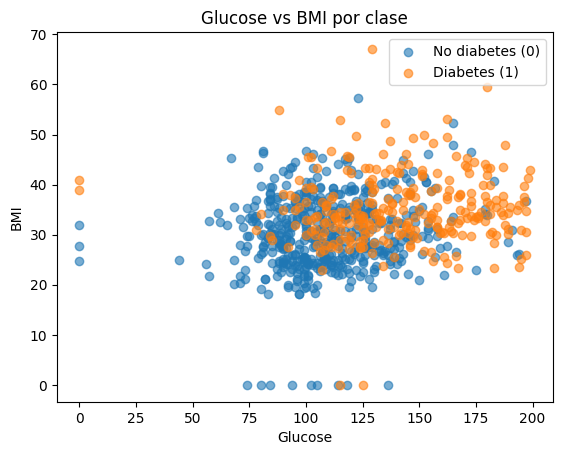

In [19]:
# Separar clases
df_0 = df[df["Outcome"] == 0]
df_1 = df[df["Outcome"] == 1]

plt.scatter(df_0["Glucose"], df_0["BMI"], label="No diabetes (0)", alpha=0.6)
plt.scatter(df_1["Glucose"], df_1["BMI"], label="Diabetes (1)", alpha=0.6)

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI por clase")
plt.legend()
plt.show()

Como parte de la exploracion de los datos es importante visualizarlos y generar interpretaciones. por ejemplo, en este gráfico cada punto representa un paciente.  

- El eje **X** muestra el nivel de **glucosa (Glucose)**  
- El eje **Y** muestra el **índice de masa corporal (BMI)**  
- Los colores indican la clase:
  - Azul → no diabetes (0)
  - Naranja → diabetes (1)

Se observan varias cosas:

- Existe una **tendencia clara**: los pacientes con diabetes (naranja) tienden a tener valores más altos de glucosa.  
- Sin embargo, **no hay una separación perfecta** entre las clases; ambas están parcialmente mezcladas.  
- El BMI también influye, pero no separa tan claramente las clases como la glucosa.  

Cuando las clases no se separan claramente en un gráfico, significa que el modelo tendrá que aprender fronteras de decisión más complejas.

## Paso 2: Preparar los datos

Antes de entrenar un modelo de clasificación, es necesario preparar los datos. Esto incluye:

- Separar las **variables de entrada** y la **variable objetivo**
- Identificar qué variables son **numéricas** y cuáles son **categóricas**
- Aplicar las transformaciones necesarias para que el modelo pueda trabajar correctamente con ellas

En este dataset, la mayoría de las variables son numéricas, pero también tenemos una variable categórica llamada **PhysicalActivity**, que debe transformarse a un formato numérico antes de entrenar los modelos.

In [20]:
# ==============================
# 1. Separar variables de entrada (X) y variable objetivo (y)
# ==============================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (768, 9)
Dimensiones de y: (768,)


- **X** contiene las variables que usará el modelo para hacer predicciones
- **y** contiene la variable objetivo, es decir, la clase que queremos predecir

En este caso:
- **X** = contiene todas las características del paciente (798 pacientes, 9 columnas)
- **y** = diabetes (768 pacientes, 1 columna)

In [21]:
# Ver primeras filas de X
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,PhysicalActivity
0,6,148,72,35,0,33.6,0.627,50,Low
1,1,85,66,29,0,26.6,0.351,31,Low
2,8,183,64,0,0,23.3,0.672,32,Medium
3,1,89,66,23,94,28.1,0.167,21,Medium
4,0,137,40,35,168,43.1,2.288,33,Low


In [22]:
# Ver primeras filas de y
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [23]:
# ==============================
# 2. Identificar variables numéricas y categóricas en X
# ==============================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Variables categóricas:
['PhysicalActivity']


En machine learning, no todas las variables se tratan de la misma forma:

- Las **variables numéricas** pueden escalarse o normalizarse. Esta es una práctica común, ya que suelen estar en **diferentes escalas y unidades** (por ejemplo, la edad puede variar entre 20 y 80 años, mientras que la glucosa puede tener valores mucho mayores). Sin escalamiento, las variables con valores más grandes pueden dominar el aprendizaje del modelo y afectar su desempeño. Escalar los datos permite que todas las variables tengan una influencia más equilibrada durante el entrenamiento.
- Las **variables categóricas** deben convertirse a formato numérico. esto se hace porque los modelos de scikit-learn no pueden trabajar directamente con texto como: Low, Medium, High. Por eso, necesitamos convertir estas categorías en números. Una forma común de hacerlo es con **One-Hot Encoding**.


Usaremos dos transformaciones principales:

#### Variables numéricas
A las variables numéricas les aplicaremos **StandardScaler**, que transforma los datos para que tengan una escala similar.

#### Variables categóricas
A la variable categórica **PhysicalActivity** le aplicaremos **OneHotEncoder**.

OneHotEncoder convertirá una columna como:

| PhysicalActivity |
|------------------|
| Low              |
| Medium           |
| High             |

en varias columnas binarias como:

| PhysicalActivity_High | PhysicalActivity_Low | PhysicalActivity_Medium |
|-----------------------|----------------------|--------------------------|
| 0                     | 1                    | 0                        |
| 0                     | 0                    | 1                        |
| 1                     | 0                    | 0                        |

En estas nuevas columnas:
- **1** indica que el paciente pertenece a esa categoría  
- **0** indica que no pertenece  

Por ejemplo, en la primera fila el paciente tiene actividad **Low**, por lo que:
- la columna *PhysicalActivity_Low* tiene valor **1** en la priemra fila
- las demás columnas tienen valor **0** en la primera fila

In [24]:
# ==============================
# 3. Crear transformaciones
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [25]:
# ==============================
# 4. Aplicar transformaciones a X
# ==============================

X_transformed = preprocessor.fit_transform(X)

print("Transformación completada")
print("Tipo de resultado:", type(X_transformed))
print("Dimensiones transformadas:", X_transformed.shape)

Transformación completada
Tipo de resultado: <class 'numpy.ndarray'>
Dimensiones transformadas: (768, 11)


In [ ]:
# ==============================
# 5. Convertir a DataFrame para visualizar el dataset X preparado
# ==============================

encoded_cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

X_prepared = pd.DataFrame(X_transformed, columns=all_feature_names)

X_prepared.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,PhysicalActivity_High,PhysicalActivity_Low,PhysicalActivity_Medium
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,0.0,1.0,0.0
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0.0,1.0,0.0
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,0.0,0.0,1.0
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,0.0,0.0,1.0
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,0.0,1.0,0.0


## Paso 3: Separar datos en entrenamiento y prueba

Para evaluar correctamente un modelo, es importante separar los datos en dos conjuntos:

- **Entrenamiento**: para que el modelo aprenda
- **Prueba**: para evaluar su desempeño en datos no vistos

Esto nos permite medir qué tan bien generaliza el modelo.

In [30]:
from sklearn.model_selection import train_test_split

#test_size controla en que proporcion se quiere dividir el conjunto. 0.2 indica 80% entrenamiento y 20% prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (614, 9)
Test: (154, 9)


## Paso 4: Entrenar modelos de clasificación

En este paso entrenaremos cuatro algoritmos de clasificación comunes:

- **Logistic Regression**
- **Decision Tree**
- **Random Forest** 
- **K-Nearest Neighbors (KNN)**

Usaremos un **Pipeline** para integrar automáticamente el preprocesamiento y el modelo. Esto asegura que las mismas transformaciones se apliquen correctamente tanto a los datos de entrenamiento como a los de prueba.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Modelo 1: Logistic Regression
model_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Modelo 2: Decision Tree
model_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Modelo 3: Random Forest
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Modelo 4: K-Nearest Neighbors
model_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

# Entrenar modelos
model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_knn.fit(X_train, y_train)

print("Modelos entrenados correctamente")

✅ Modelos entrenados correctamente


## Paso 5: Evaluar resultados y comparar modelos entrenados

Ahora evaluaremos los modelos sobre los datos de prueba usando varias métricas de clasificación:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**

Estas métricas nos permiten entender no solo cuántas predicciones fueron correctas, sino también cómo se comporta el modelo al identificar cada clase.

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_models(models, X_test, y_test):
    results = []
    
    for name, model in models.items():
        y_pred = model.predict(X_test)
        
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        })
    
    results_df = pd.DataFrame(results)
    return results_df.sort_values(by="F1-score", ascending=False)

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}

results_df = evaluate_models(models, X_test, y_test)
results_df

,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.753247,0.653846,0.629630,0.641509
3,KNN,0.733766,0.627451,0.592593,0.609524
0,Logistic Regression,0.720779,0.617021,0.537037,0.574257
1,Decision Tree,0.733766,0.666667,0.481481,0.559140


Los resultados muestran que **Random Forest** es el modelo con mejor desempeño general, ya que obtiene el mayor **F1-score** y un buen balance entre *precision* y *recall*. **KNN** también presenta un rendimiento sólido, aunque ligeramente inferior. Por su parte, la **Regresión Logística** tiene el menor recall, lo que indica que detecta menos casos positivos. Finalmente, el **Decision Tree** logra una buena precisión, pero su bajo recall sugiere que falla en identificar varios pacientes con diabetes. En conjunto, Random Forest destaca como la mejor opción bajo estas métricas.

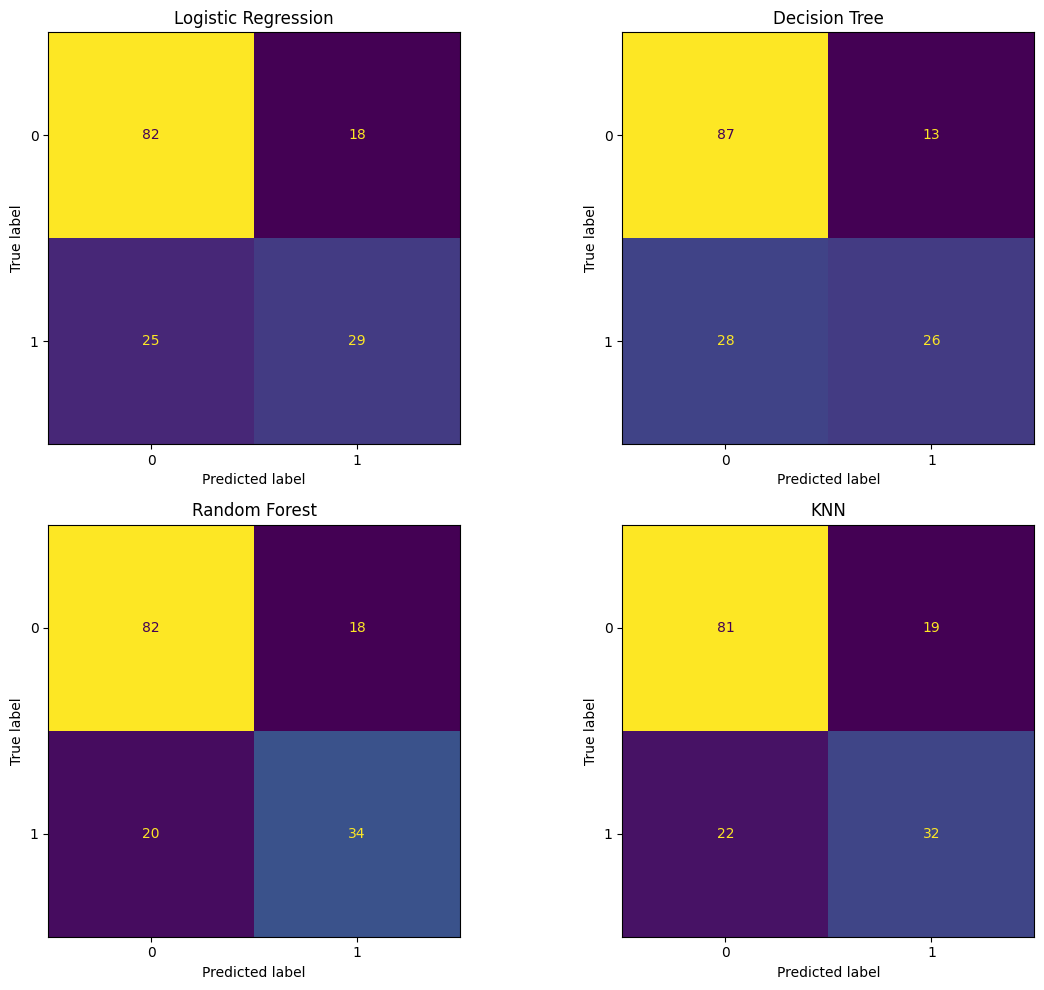

In [ ]:
=============
#Podemos visualizar las matrices de confusion para cada modelo
=============
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_list = list(models.items())

for i, (name, model) in enumerate(models_list):
    row = i // 2
    col = i % 2
    
    ConfusionMatrixDisplay.from_estimator(
        model, 
        X_test, 
        y_test, 
        ax=axes[row, col],
        colorbar=False
    )
    
    axes[row, col].set_title(name)

plt.tight_layout()
plt.show()

## Paso 6: Analizar probabilidades y umbral de clasificación

Algunos modelos como regresion logistica no solo predicen una clase, sino también la **probabilidad** de que un ejemplo pertenezca a la clase positiva.

Por defecto, el umbral de decisión suele ser **0.5**:

- Si la probabilidad es mayor o igual a 0.5 → el modelo predice **1**
- Si la probabilidad es menor a 0.5 → el modelo predice **0**

Podemos modificar este umbral para hacer el modelo más sensible o más conservador.

In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Probabilidades con Logistic Regression
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Cambiar threshold
threshold = 0.3
y_pred_custom = (y_proba_lr >= threshold).astype(int)

print("Threshold seleccionado:", threshold)
print("\nMatriz de confusión con threshold personalizado:")
print(confusion_matrix(y_test, y_pred_custom))

Threshold seleccionado: 0.3

Matriz de confusión con threshold personalizado:
[[75 25]
 [ 9 45]]


Reducir el threshold puede ayudar a detectar más casos positivos, pero también puede aumentar los falsos positivos. En problemas médicos, esto es importante, ya que en muchos casos es preferible detectar más pacientes en riesgo, incluso si eso produce algunas falsas alarmas.

## Paso 6: Visualizar curva ROC y AUC

La **curva ROC** permite analizar el desempeño del modelo para distintos valores de threshold.

El **AUC** (*Area Under the Curve*) resume esta curva en un solo valor:

- Un AUC cercano a **1.0** indica muy buena capacidad de discriminación
- Un AUC cercano a **0.5** indica que el modelo no distingue bien entre clases

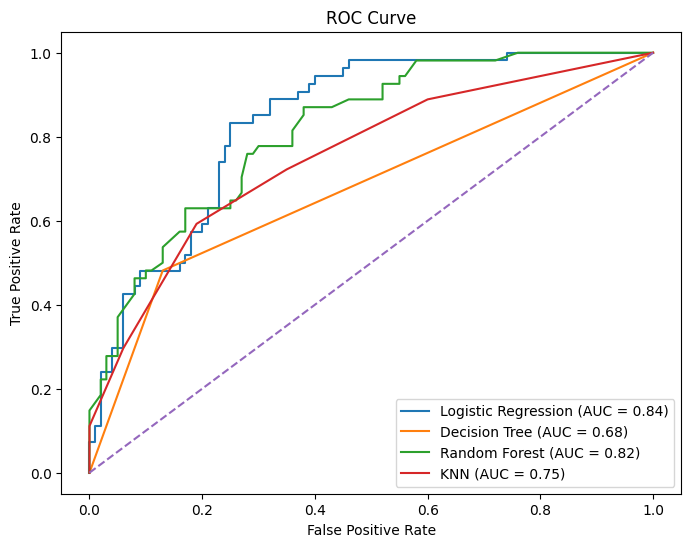

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}

auc_scores = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    auc_scores[name] = auc
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Interpretación de la curva ROC

La curva ROC muestra la capacidad de cada modelo para distinguir entre pacientes con y sin diabetes a diferentes valores de umbral (*threshold*). El eje X representa la tasa de falsos positivos (*False Positive Rate*), mientras que el eje Y representa la tasa de verdaderos positivos (*True Positive Rate*). La línea diagonal punteada indica el desempeño de un modelo aleatorio, es decir, sin capacidad de discriminación.

Al observar la gráfica, se puede notar que la **Regresión Logística (AUC = 0.84)** es el modelo con mejor desempeño, ya que su curva se acerca más a la esquina superior izquierda. Esto indica que logra un buen equilibrio entre detectar correctamente los casos positivos y minimizar los falsos positivos. De manera similar, el **Random Forest (AUC = 0.82)** también muestra un desempeño alto y muy cercano al de la regresión logística.

Por otro lado, el modelo **KNN (AUC = 0.75)** presenta un rendimiento intermedio: es claramente mejor que el azar, pero no alcanza el nivel de los dos modelos anteriores. Finalmente, el **Decision Tree (AUC = 0.68)** es el modelo con menor desempeño, ya que su curva está más cerca de la línea diagonal, lo que indica una menor capacidad para diferenciar entre las clases.

En conclusión, todos los modelos tienen cierta capacidad predictiva (AUC mayor a 0.5), pero los mejores resultados se obtienen con **Regresión Logística** y **Random Forest**. La curva ROC permite comparar modelos de forma más completa que solo usando accuracy, ya que evalúa su desempeño a lo largo de distintos umbrales de decisión.

### ¿Por qué los resultados de la curva ROC dicen que regresion logistica es mejor mientras que al comparar los modelos en el paso 5 ramdon forest mostro mejor capcidad predictiva?

A primera vista, parece que hay una inconsistencia entre las métricas y la curva ROC. Por ejemplo, **Random Forest** tiene el mejor F1-score, mientras que en la curva ROC la **Regresión Logística** tiene el mejor AUC.

Sin embargo, esto es completamente normal y tiene una explicación importante. Las métricas como **Accuracy, Precision, Recall y F1-score** se calculan usando un único umbral de decisión (generalmente 0.5). Es decir, el modelo convierte las probabilidades en clases (0 o 1) usando ese valor fijo.

Por otro lado, la **curva ROC y el AUC** evalúan el modelo considerando **todos los posibles valores de umbral**. Esto mide qué tan bien el modelo puede separar las clases en general, independientemente de un threshold específico.

Esto significa que:

- **Random Forest** funciona mejor cuando usamos el umbral por defecto (0.5)  
- **Logistic Regression** tiene mejor capacidad general para separar las clases (mejor ranking de probabilidades)  

En otras palabras, un modelo puede:
- Tener mejor desempeño en clasificación directa (F1, accuracy)  
- Pero otro puede ser mejor en términos de discriminación global (AUC)


## Paso 8: Comparar modelos y discutir cuál funciona mejor

Entonces, para comparar los modelos de forma más ordenada, crearemos una tabla resumen con algunas métricas principales.

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.720779,0.617021,0.537037,0.574257,0.837037
2,Random Forest,0.753247,0.653846,0.629630,0.641509,0.815463
3,KNN,0.733766,0.627451,0.592593,0.609524,0.754352
1,Decision Tree,0.733766,0.666667,0.481481,0.559140,0.675741


### Conclusión final

Considerando todas las métricas, **Random Forest** es el modelo más adecuado para este problema. Presenta el mejor **F1-score**, así como un buen balance entre *precision* y *recall*, lo que indica que logra detectar correctamente los casos de diabetes sin generar demasiados falsos positivos. Además, obtiene la mayor **accuracy** entre los modelos evaluados.

Aunque la **Regresión Logística** tiene el mejor AUC, lo que indica una buena capacidad general de discriminación, su desempeño con el umbral por defecto es inferior en términos de recall y F1-score. Dado que en este contexto es importante identificar correctamente a los pacientes con diabetes, **Random Forest ofrece el mejor compromiso entre las métricas evaluadas** y se considera la mejor opción.

# Actividad: Clasificación de clientes para compra de seguro

Fuente de datos: https://github.com/singhn156/Car-Insurance-Prediction

## Objetivo
En esta actividad, aplicarás el mismo proceso de clasificación visto previamente, pero ahora con un nuevo dataset del mundo real. El objetivo es predecir si un cliente comprará un seguro de automóvil (**CarInsurance**) a partir de sus características.

## Descripción del dataset

El dataset contiene información de clientes contactados durante una campaña de marketing de un banco.

La variable objetivo es:

- **CarInsurance**
  - 1 → el cliente compró el seguro  
  - 0 → el cliente no compró el seguro  

Este es un problema de **clasificación binaria**.

Las variables predictoras (**X**) incluyen diferentes tipos de información sobre los clientes:

### Datos demográficos
- **Age**: edad del cliente  
- **Job**: tipo de trabajo (ej. admin, blue-collar, etc.)  
- **Marital**: estado civil (soltero, casado, divorciado)  
- **Education**: nivel educativo  

### Información financiera
- **Balance**: balance promedio anual en USD  
- **Default**: indica si el cliente tiene crédito en incumplimiento (1 = sí, 0 = no)  
- **HHInsurance**: indica si el hogar está asegurado  
- **CarLoan**: indica si el cliente tiene un préstamo de automóvil  

### Información de la campaña
- **NoOfContacts**: número de contactos durante la campaña actual   
- **PrevAttempts**: número de intentos previos de contacto  

**Nota**: Este dataset combina variables numéricas y categóricas, lo que lo hace ideal para practicar técnicas de preprocesamiento como escalamiento y codificación (*encoding*).

---

## Entregable

Debes repetir el flujo completo de machine learning visto en este notebook en un archivo nuevo como entregable e incluir los siguientes componentes:

---

### 1. Carga y exploración de datos
- Cargar el dataset
- Mostrar las primeras filas
- Revisar tipos de variables
- Identificar valores nulos
- Analizar la distribución de la variable objetivo

**Pregunta:**

¿El dataset está balanceado?

---

### 2. Preparación de los datos

- Separar variables de entrada (X) y objetivo (y)
- Identificar:
  - variables numéricas
  - variables categóricas
- Aplicar:
  - **StandardScaler** para variables numéricas  
  - **OneHotEncoder** para variables categóricas  

**Pregunta:**
- ¿Qué variables son categóricas y por qué necesitan transformación?

---

### 3. Separar entrenamiento y prueba

- Usar `train_test_split`
- Mantener proporción de clases (`stratify`)

**Pregunta:**
¿Por qué es importante separar train/test?

---

### 4. Entrenar modelos

Entrena los siguientes modelos:

- Logistic Regression  
- Decision Tree  
- Random Forest  
- K-Nearest Neighbors  

---

### 5. Evaluación

Evalúa inicialmente cada modelo usando:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- Matriz de confusión  

**Pregunta:**
¿Qué modelo tiene mejor desempeño y por qué?

---

### 6. Probabilidades y threshold

- Obtener probabilidades (`predict_proba`)
- Cambiar el threshold (ej: 0.3)

**Pregunta:**
¿Qué ocurre cuando reduces el threshold?

---

### 7. Curva ROC y AUC

- Graficar la curva ROC para cada modelo
- Calcular AUC

**Pregunta:**
- ¿Qué modelo tiene mejor capacidad de discriminación?

---

### 8. Comparación final

- Crear una tabla comparativa de modelos
- Analizar resultados

**Preguntas finales:**
- ¿Qué modelo elegirías y por qué?
- ¿Cambiarías tu decisión dependiendo del contexto (ej. marketing vs medicina)?

---